# Q1. Image Resizing, Interpolation, and Edge Analysis

This notebook:
1. Uses a standard 512×512 grayscale image.
2. Downsamples it to 256×256 and 128×128.
3. Reconstructs each image to 512×512 using manually implemented:
   - Nearest-neighbour interpolation
   - Bilinear interpolation
   - Bicubic interpolation
4. Computes MSE and PSNR.
5. Displays absolute-error and squared-error maps.
6. Tabulates results and identifies the best method.


Original image size: (512, 512)


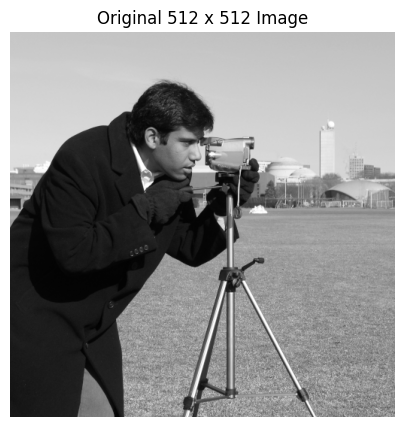

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from skimage import data

original = data.camera().astype(np.float64)

print("Original image size:", original.shape)

plt.figure(figsize=(5, 5))
plt.imshow(original, cmap="gray")
plt.title("Original 512 x 512 Image")
plt.axis("off")
plt.show()

## 1. Downsampling without using a built-in resize function

256 image size: (256, 256)
128 image size: (128, 128)


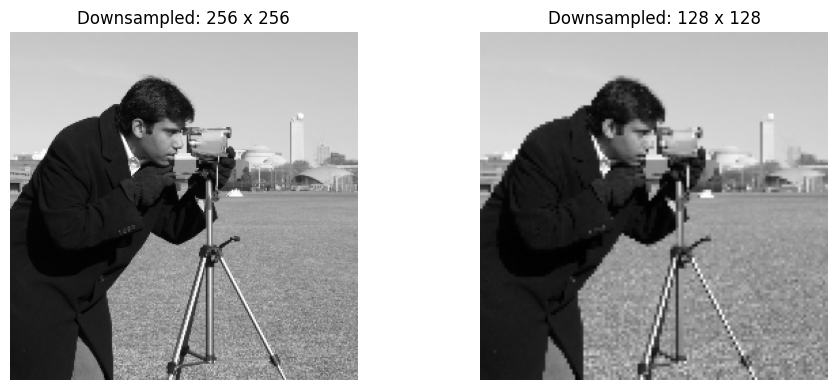

In [3]:
def downsample(image, factor):
    return image[::factor, ::factor]

img_256 = downsample(original, 2)
img_128 = downsample(original, 4)

print("256 image size:", img_256.shape)
print("128 image size:", img_128.shape)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_256, cmap="gray")
plt.title("Downsampled: 256 x 256")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_128, cmap="gray")
plt.title("Downsampled: 128 x 128")
plt.axis("off")

plt.tight_layout()
plt.show()

## 2. Nearest-Neighbour Interpolation

In [4]:
def nearest_neighbor_interpolation(image, new_height, new_width):
    old_height, old_width = image.shape
    result = np.zeros((new_height, new_width), dtype=np.float64)

    scale_y = old_height / new_height
    scale_x = old_width / new_width

    for i in range(new_height):
        for j in range(new_width):
            old_i = int(round(i * scale_y))
            old_j = int(round(j * scale_x))

            old_i = min(old_i, old_height - 1)
            old_j = min(old_j, old_width - 1)

            result[i, j] = image[old_i, old_j]

    return result

## 3. Bilinear Interpolation

In [5]:
def bilinear_interpolation(image, new_height, new_width):
    old_height, old_width = image.shape
    result = np.zeros((new_height, new_width), dtype=np.float64)

    scale_y = old_height / new_height
    scale_x = old_width / new_width

    for i in range(new_height):
        for j in range(new_width):
            y = i * scale_y
            x = j * scale_x

            y0 = int(np.floor(y))
            x0 = int(np.floor(x))

            y1 = min(y0 + 1, old_height - 1)
            x1 = min(x0 + 1, old_width - 1)

            dy = y - y0
            dx = x - x0

            Q11 = image[y0, x0]
            Q12 = image[y0, x1]
            Q21 = image[y1, x0]
            Q22 = image[y1, x1]

            result[i, j] = (
                Q11 * (1 - dx) * (1 - dy) +
                Q12 * dx * (1 - dy) +
                Q21 * (1 - dx) * dy +
                Q22 * dx * dy
            )

    return result

## 4. Bicubic Interpolation

In [6]:
def cubic_weight(x, a=-0.5):
    x = abs(x)

    if x <= 1:
        return (a + 2) * x**3 - (a + 3) * x**2 + 1
    elif x < 2:
        return a * x**3 - 5 * a * x**2 + 8 * a * x - 4 * a
    else:
        return 0


def bicubic_interpolation(image, new_height, new_width):
    old_height, old_width = image.shape
    result = np.zeros((new_height, new_width), dtype=np.float64)

    scale_y = old_height / new_height
    scale_x = old_width / new_width

    for i in range(new_height):
        for j in range(new_width):
            y = i * scale_y
            x = j * scale_x

            y_int = int(np.floor(y))
            x_int = int(np.floor(x))

            value = 0
            weight_sum = 0

            # Bicubic interpolation uses a 4 x 4 neighbourhood = 16 pixels
            for m in range(-1, 3):
                for n in range(-1, 3):
                    yy = min(max(y_int + m, 0), old_height - 1)
                    xx = min(max(x_int + n, 0), old_width - 1)

                    wy = cubic_weight(y - (y_int + m))
                    wx = cubic_weight(x - (x_int + n))

                    weight = wy * wx
                    value += image[yy, xx] * weight
                    weight_sum += weight

            if weight_sum != 0:
                result[i, j] = value / weight_sum

    return np.clip(result, 0, 255)

## 5. Reconstruct Both Downsampled Images to 512×512

In [7]:
print("Processing 256 x 256 image...")
nn_256 = nearest_neighbor_interpolation(img_256, 512, 512)
bilinear_256 = bilinear_interpolation(img_256, 512, 512)
bicubic_256 = bicubic_interpolation(img_256, 512, 512)

print("Processing 128 x 128 image...")
nn_128 = nearest_neighbor_interpolation(img_128, 512, 512)
bilinear_128 = bilinear_interpolation(img_128, 512, 512)
bicubic_128 = bicubic_interpolation(img_128, 512, 512)

print("Reconstruction completed.")

Processing 256 x 256 image...
Processing 128 x 128 image...
Reconstruction completed.


## 6. MSE and PSNR

In [8]:
def calculate_mse(original, reconstructed):
    return np.mean((original - reconstructed) ** 2)


def calculate_psnr(original, reconstructed):
    mse = calculate_mse(original, reconstructed)

    if mse == 0:
        return float("inf")

    return 10 * np.log10((255 ** 2) / mse)


all_images = {
    "256 -> Nearest Neighbour": nn_256,
    "256 -> Bilinear": bilinear_256,
    "256 -> Bicubic": bicubic_256,
    "128 -> Nearest Neighbour": nn_128,
    "128 -> Bilinear": bilinear_128,
    "128 -> Bicubic": bicubic_128
}

results = []

for name, image in all_images.items():
    mse = calculate_mse(original, image)
    psnr = calculate_psnr(original, image)

    results.append({
        "Method": name,
        "MSE": mse,
        "PSNR (dB)": psnr
    })

df = pd.DataFrame(results)
df

,Method,MSE,PSNR (dB)
0,256 -> Nearest Neighbour,182.377865,25.521082
1,256 -> Bilinear,81.205832,29.034931
2,256 -> Bicubic,82.184200,28.982920
3,128 -> Nearest Neighbour,344.522987,22.758622
4,128 -> Bilinear,208.204380,24.945905
5,128 -> Bicubic,217.203455,24.762136


## 7. Pixel-wise Absolute-Error and Squared-Error Maps

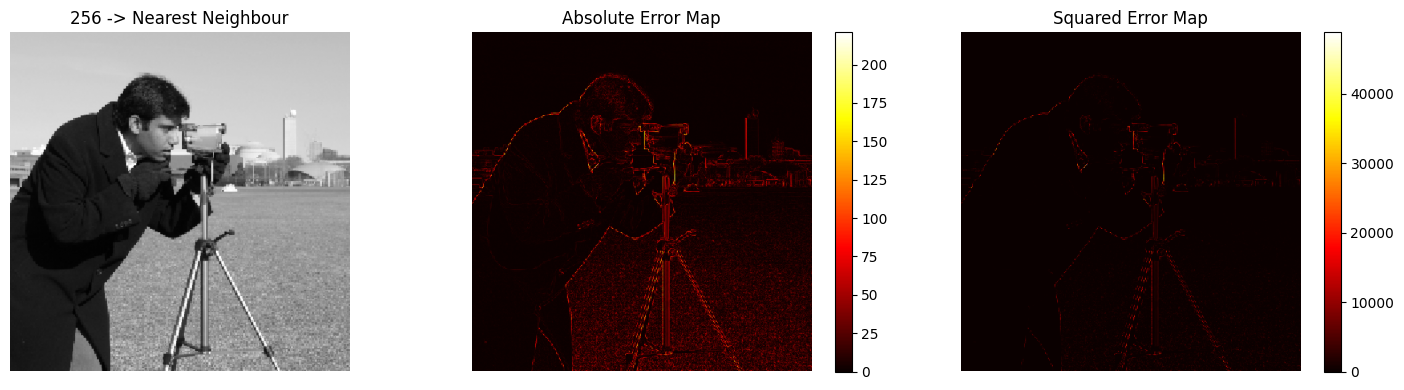

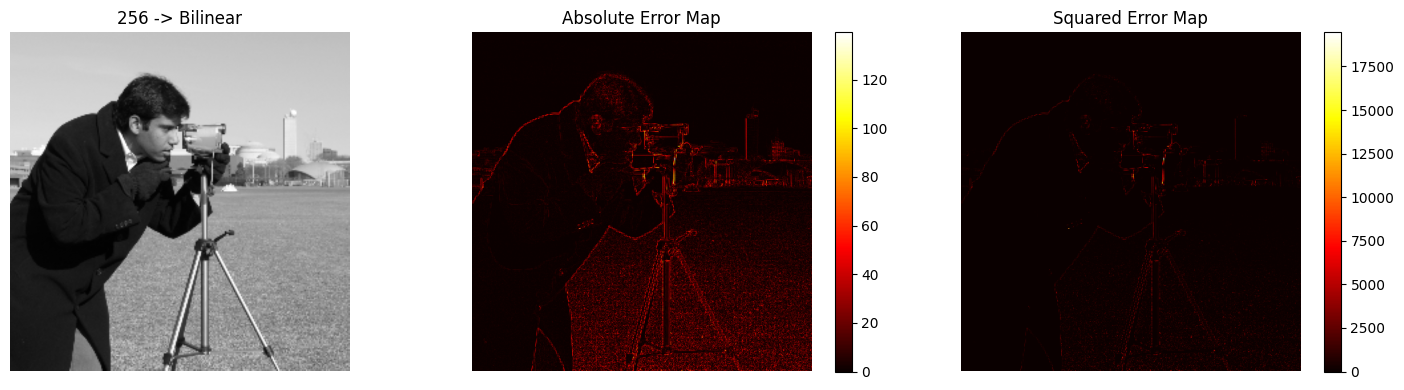

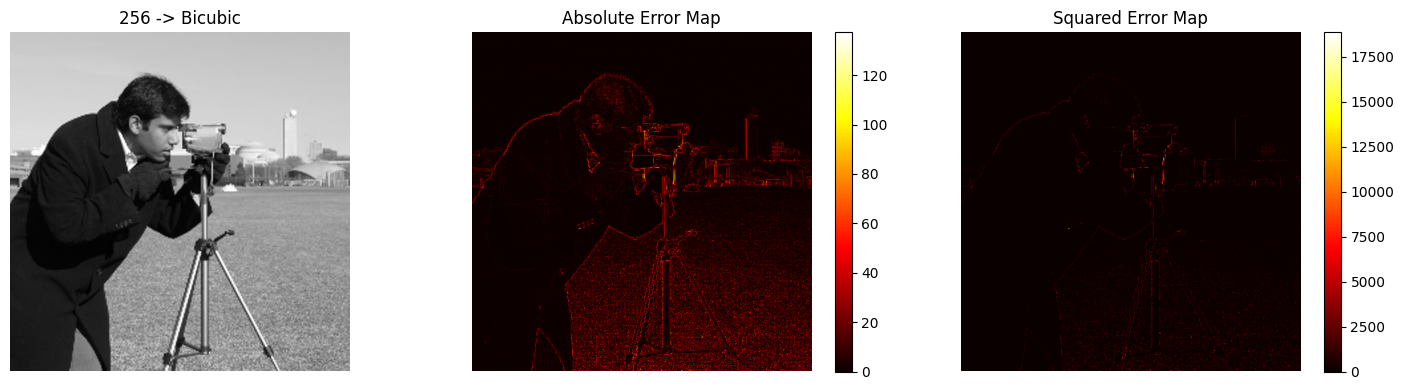

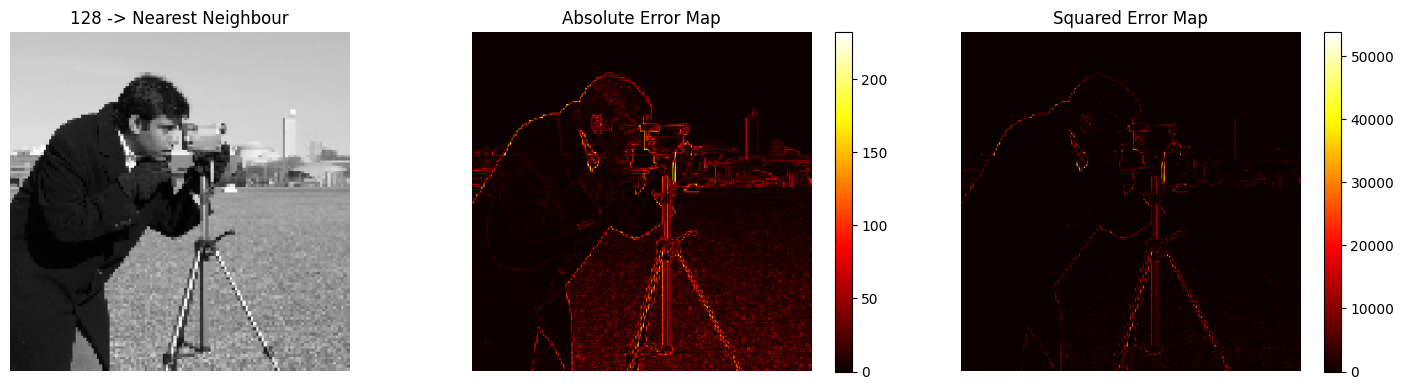

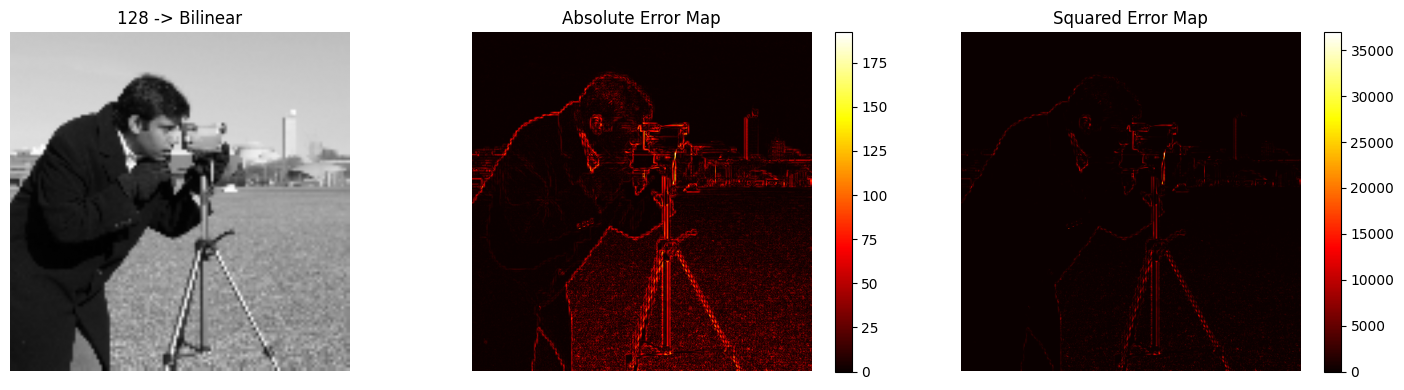

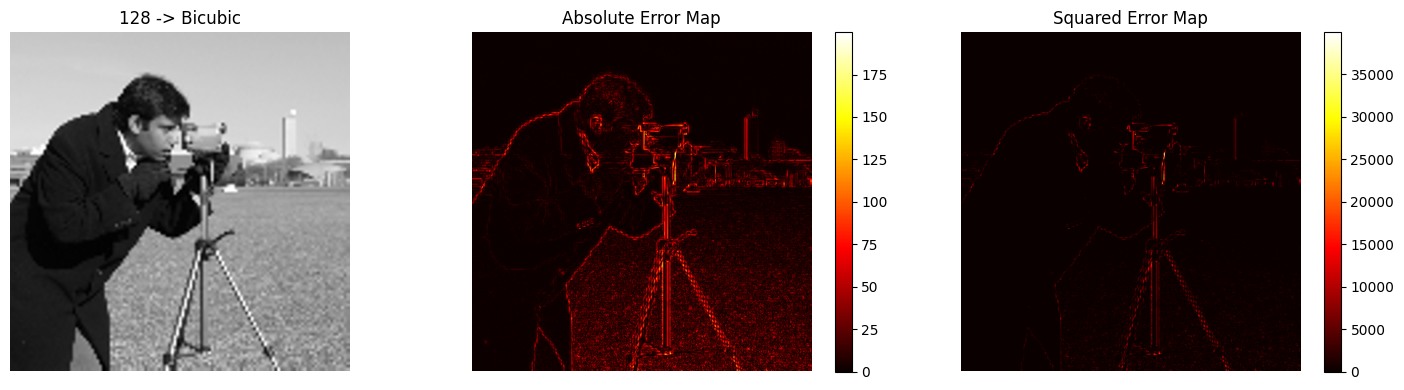

In [9]:
def display_error_maps(name, original, reconstructed):
    absolute_error = np.abs(original - reconstructed)
    squared_error = (original - reconstructed) ** 2

    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(reconstructed, cmap="gray")
    plt.title(name)
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(absolute_error, cmap="hot")
    plt.title("Absolute Error Map")
    plt.colorbar()
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(squared_error, cmap="hot")
    plt.title("Squared Error Map")
    plt.colorbar()
    plt.axis("off")

    plt.tight_layout()
    plt.show()


for name, image in all_images.items():
    display_error_maps(name, original, image)

## 8. Visual Comparison

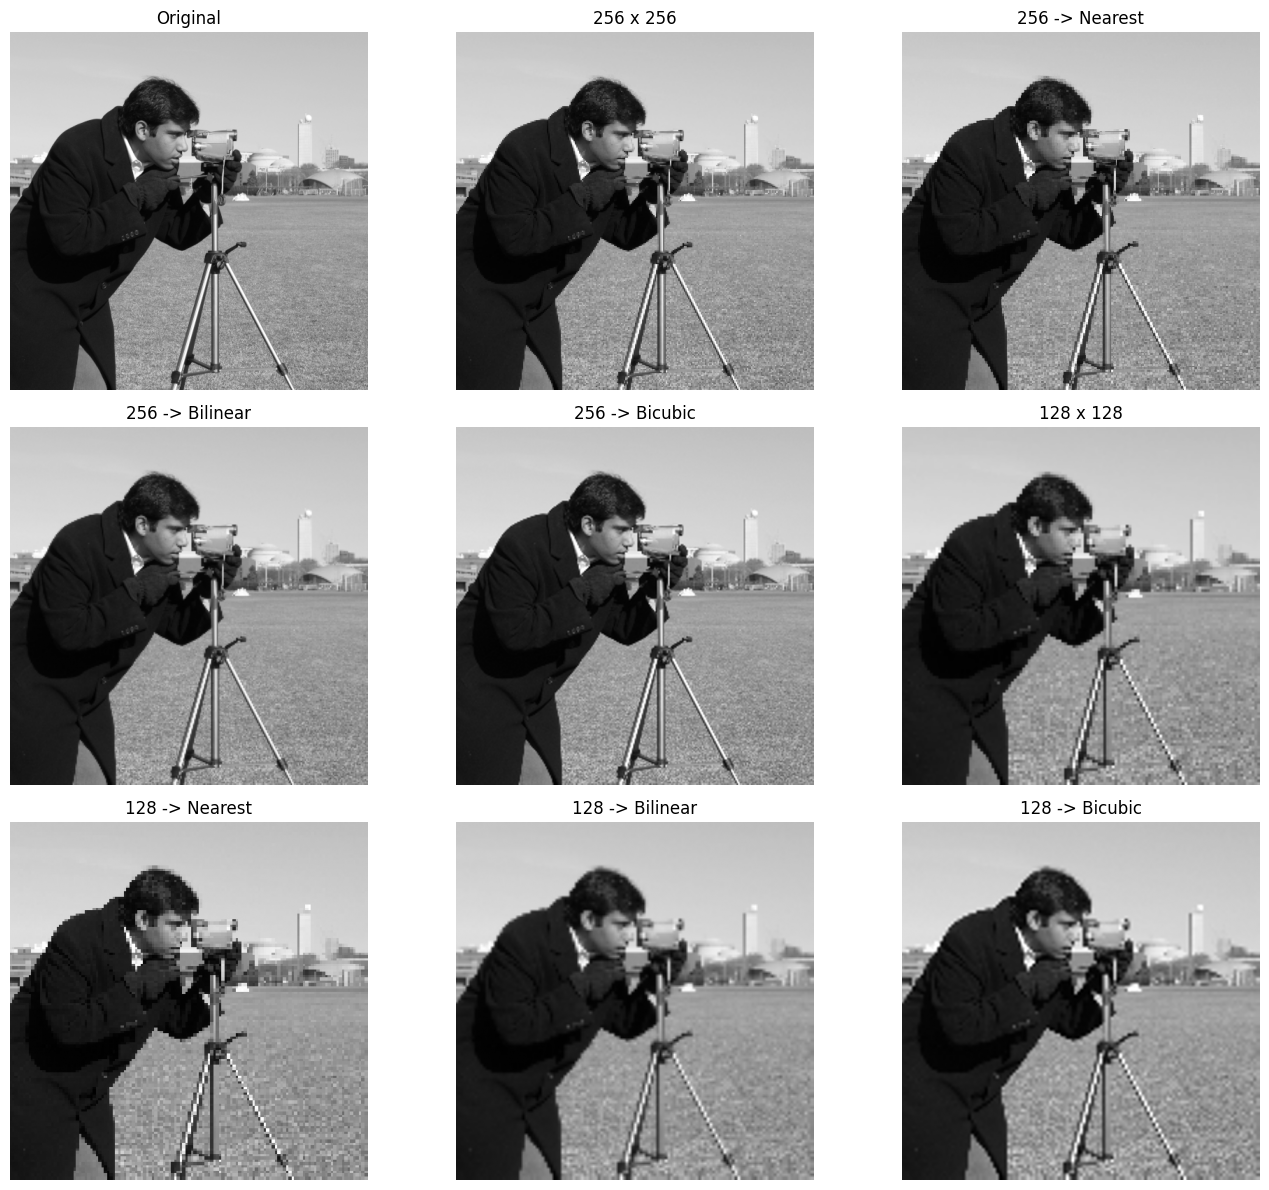

In [10]:
images_to_display = [
    ("Original", original),
    ("256 x 256", img_256),
    ("256 -> Nearest", nn_256),
    ("256 -> Bilinear", bilinear_256),
    ("256 -> Bicubic", bicubic_256),
    ("128 x 128", img_128),
    ("128 -> Nearest", nn_128),
    ("128 -> Bilinear", bilinear_128),
    ("128 -> Bicubic", bicubic_128)
]

plt.figure(figsize=(14, 12))

for k, (title, image) in enumerate(images_to_display):
    plt.subplot(3, 3, k + 1)
    plt.imshow(image, cmap="gray")
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

## 9. Identify the Best-Performing Method

In [11]:
best_method = df.loc[df["MSE"].idxmin()]

print("BEST PERFORMING METHOD")
print("----------------------")
print("Method:", best_method["Method"])
print("MSE:", best_method["MSE"])
print("PSNR (dB):", best_method["PSNR (dB)"])

BEST PERFORMING METHOD
----------------------
Method: 256 -> Bilinear
MSE: 81.20583200454712
PSNR (dB): 29.034931405375595


## 10. Discussion

### Effect of interpolation method
- **Nearest-neighbour interpolation** copies the nearest pixel value. It is computationally simple, but the reconstructed image generally appears blocky or pixelated.
- **Bilinear interpolation** uses four neighbouring pixels, producing smoother transitions. However, this can blur sharp edges.
- **Bicubic interpolation** uses a 4×4 neighbourhood (16 pixels). It generally provides the best visual quality and a better balance between smoothness and edge preservation.

### Effect of downsampling factor
- The **256×256 image** retains more information from the original 512×512 image, so its reconstruction generally has lower MSE and higher PSNR.
- The **128×128 image** loses more fine details during downsampling. When enlarged back to 512×512, the lost information cannot be fully recovered, resulting in larger reconstruction errors and weaker edge preservation.

### Overall conclusion
The best-performing method should be identified from the results table. In general, **bicubic interpolation is expected to provide the best visual quality and edge preservation**, while the exact MSE and PSNR values depend on the image and downsampling method.
